# Deep Learning Volatility — a neural pricing map for Heston

Reproduces the method of Horvath, Muguruza & Tomas (2019) on the Heston model:
a neural network learns the map **Heston parameters → implied-vol surface** on
a fixed 8×11 grid, trained offline against the C++ Fourier pricer. Calibration
then inverts the fast, differentiable network in milliseconds.

This notebook loads the trained network (`deep_calibration/train.py`) and a
held-out test set, and shows: (1) approximation accuracy, (2) a calibration
round-trip, (3) the surrogate speed-up.

In [1]:
import sys
import pathlib
import time

import numpy as np
import matplotlib
try:
    get_ipython()  # noqa: F821  -- only defined inside a Jupyter/IPython kernel
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch

torch.set_num_threads(1)  # tiny network: single thread is fastest

if "__file__" in globals():
    _HERE = pathlib.Path(__file__).resolve().parent
else:  # executed as a notebook (cwd is the notebooks/ directory)
    _HERE = pathlib.Path.cwd()
_DC = _HERE.parent / "deep_calibration"
sys.path.insert(0, str(_DC))
from calibrate import load_model, calibrate_surface  # noqa: E402

IMG = _HERE / "img"
IMG.mkdir(exist_ok=True)

model, ckpt = load_model(str(_DC / "models" / "surface_mlp.pt"))
maturities = np.asarray(ckpt["maturities"])
strikes = np.asarray(ckpt["strikes"])
param_names = [str(s) for s in ckpt["param_names"]]
n_mat, n_strk = maturities.size, strikes.size

test = np.load(_DC / "data" / "heston_iv_test.npz", allow_pickle=True)
Xte, Yte = test["X"], test["Y"]
print(f"loaded network ({sum(p.numel() for p in model.net.parameters())} weights) "
      f"and {Xte.shape[0]} held-out surfaces")

loaded network (5698 weights) and 1000 held-out surfaces


## 1. Approximation accuracy (held-out surfaces)
The error map shows where the network is least accurate: the short-maturity
wings, exactly where the true surface is steepest — consistent with the paper.

out-of-sample:  RMSE 10.4 bps   MAE 4.3 bps   95th pct 11.9 bps   max 541 bps


saved C:\Users\SCA\Desktop\claude nonsense\code\heston_model_pricing_and_calibration\notebooks\img\dnn_accuracy.png


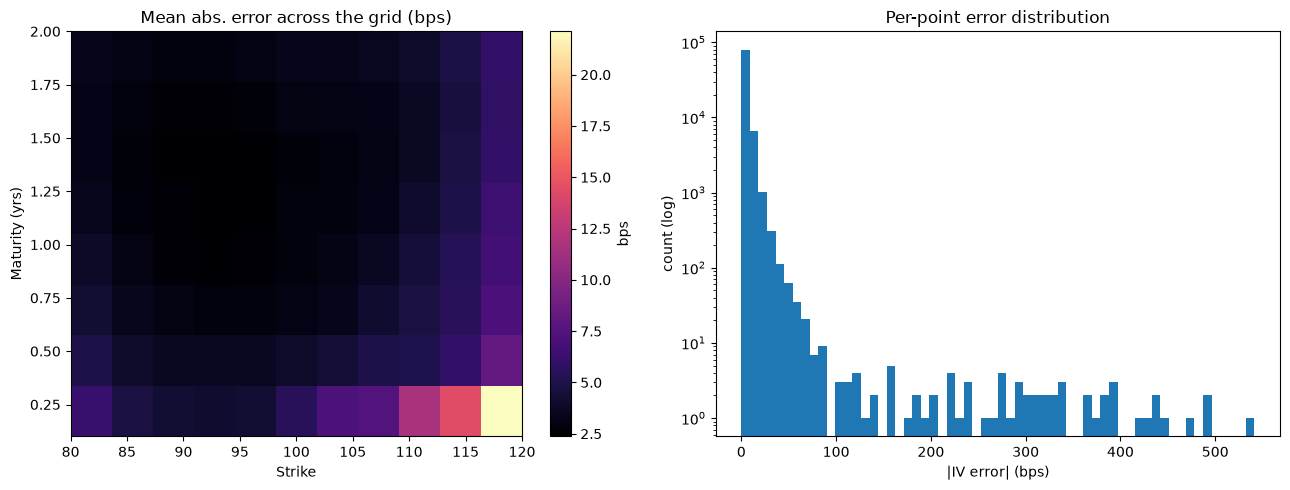

In [2]:
with torch.no_grad():
    Pte = model(torch.tensor(Xte, dtype=torch.float32)).numpy()
err = Pte - Yte
rmse_bps = np.sqrt((err ** 2).mean()) * 1e4
mae_bps = np.abs(err).mean() * 1e4
print(f"out-of-sample:  RMSE {rmse_bps:.1f} bps   MAE {mae_bps:.1f} bps   "
      f"95th pct {np.percentile(np.abs(err), 95)*1e4:.1f} bps   max {np.abs(err).max()*1e4:.0f} bps")

mae_grid = np.abs(err).mean(0).reshape(n_mat, n_strk) * 1e4
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
im = a1.imshow(mae_grid, aspect="auto", origin="lower", cmap="magma",
               extent=[strikes[0], strikes[-1], maturities[0], maturities[-1]])
a1.set_xlabel("Strike"); a1.set_ylabel("Maturity (yrs)")
a1.set_title("Mean abs. error across the grid (bps)")
fig.colorbar(im, ax=a1, label="bps")
a2.hist(np.abs(err).flatten() * 1e4, bins=60, color="C0")
a2.set_yscale("log"); a2.set_xlabel("|IV error| (bps)"); a2.set_ylabel("count (log)")
a2.set_title("Per-point error distribution")
fig.tight_layout(); fig.savefig(IMG / "dnn_accuracy.png", dpi=130)
print("saved", IMG / "dnn_accuracy.png"); plt.show()

## A sample surface: network vs. Fourier ground truth
Smiles at three maturities for one held-out parameter set — the network
(lines) overlays the Fourier-generated truth (dots).

saved C:\Users\SCA\Desktop\claude nonsense\code\heston_model_pricing_and_calibration\notebooks\img\dnn_surface_fit.png


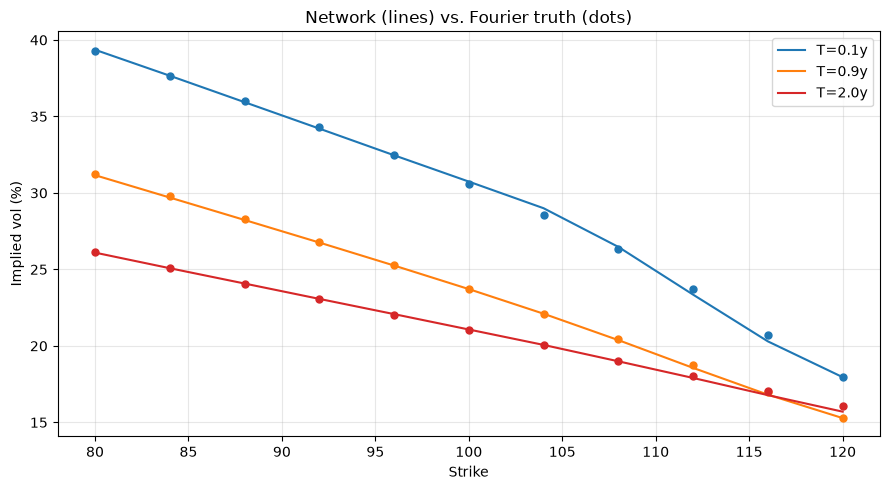

In [3]:
i = 7
fig, ax = plt.subplots(figsize=(9, 5))
true = Yte[i].reshape(n_mat, n_strk)
pred = Pte[i].reshape(n_mat, n_strk)
for row, c in zip((0, 3, 7), ("C0", "C1", "C3")):
    ax.plot(strikes, true[row] * 100, "o", color=c, ms=5)
    ax.plot(strikes, pred[row] * 100, "-", color=c, label=f"T={maturities[row]:.1f}y")
ax.set_xlabel("Strike"); ax.set_ylabel("Implied vol (%)")
ax.set_title("Network (lines) vs. Fourier truth (dots)")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(IMG / "dnn_surface_fit.png", dpi=130)
print("saved", IMG / "dnn_surface_fit.png"); plt.show()

## 2. Calibration round-trip
Treat a held-out Fourier surface as the "market", and recover the parameters
by inverting the network (LBFGS through autodiff). The surface is fit to a few
bps in milliseconds; parameter recovery is limited by the well-known Heston
identifiability (κ/σ trade-off), not by the method.

  param      true   recovered
     v0    0.1017      0.1017
  kappa    1.5230      1.5508
  theta    0.0491      0.0494
  sigma    0.6629      0.6638
    rho   -0.9402     -0.9379
surface fit RMSE 12.7 bps   in 122 ms


saved C:\Users\SCA\Desktop\claude nonsense\code\heston_model_pricing_and_calibration\notebooks\img\dnn_calibration.png


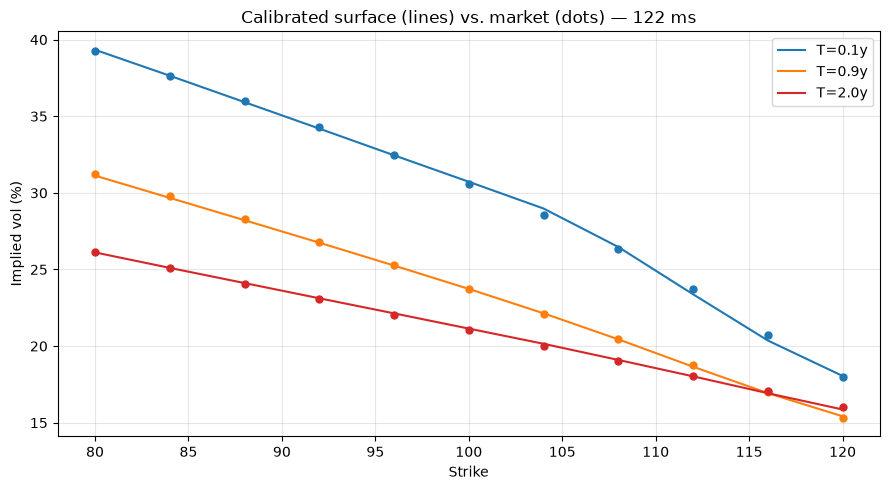

In [4]:
res = calibrate_surface(model, Yte[i], n_restarts=6, max_iter=100)
_ = calibrate_surface(model, Yte[i], n_restarts=6, max_iter=100)  # timed (warm)
res = calibrate_surface(model, Yte[i], n_restarts=6, max_iter=100)
print(f"{'param':>7} {'true':>9} {'recovered':>11}")
for name, t, r in zip(param_names, Xte[i], res["params"]):
    print(f"{name:>7} {t:>9.4f} {r:>11.4f}")
print(f"surface fit RMSE {res['rmse']*1e4:.1f} bps   in {res['seconds']*1e3:.0f} ms")

rec = res["iv"].reshape(n_mat, n_strk)
fig, ax = plt.subplots(figsize=(9, 5))
for row, c in zip((0, 3, 7), ("C0", "C1", "C3")):
    ax.plot(strikes, true[row] * 100, "o", color=c, ms=5)
    ax.plot(strikes, rec[row] * 100, "-", color=c, label=f"T={maturities[row]:.1f}y")
ax.set_xlabel("Strike"); ax.set_ylabel("Implied vol (%)")
ax.set_title(f"Calibrated surface (lines) vs. market (dots) — {res['seconds']*1e3:.0f} ms")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(IMG / "dnn_calibration.png", dpi=130)
print("saved", IMG / "dnn_calibration.png"); plt.show()

## 3. Surrogate speed-up
The network prices a full 88-point surface with a few small matrix products.
The C++ Fourier engine takes ~124 ms per surface (8×11 options, 4000-node
Simpson quadrature, measured on this machine); the network is orders of
magnitude faster, which is exactly what lifts the calibration bottleneck.

In [5]:
Xbig = torch.tensor(np.repeat(Xte, 20, axis=0), dtype=torch.float32)  # ~20k surfaces
with torch.no_grad():
    _ = model(Xbig[:100])  # warm
    t0 = time.perf_counter()
    _ = model(Xbig)
    dt = time.perf_counter() - t0
per_surface_us = dt / Xbig.shape[0] * 1e6
fourier_ms = 124.0
print(f"network: {per_surface_us:.1f} µs/surface   ({Xbig.shape[0]} surfaces in {dt*1e3:.0f} ms)")
print(f"Fourier: {fourier_ms:.0f} ms/surface")
print(f"speed-up: ~{fourier_ms*1e3/per_surface_us:,.0f}x")

network: 1.0 µs/surface   (20000 surfaces in 21 ms)
Fourier: 124 ms/surface
speed-up: ~118,909x
